# ⛅ Weather Forecast Chatbot
### NLP + Machine Learning Project
---
**Project Tasks:**
- Task 1: Dataset Loading & Exploration
- Task 2: NLP Processing (Tokenization, Stemming, Lemmatization, Stopwords)
- Task 3: Vocabulary & Matching (NER, Noun Chunks, Patterns, Display Diagram)
- Task 4: Text Classification using Logistic Regression
- Task 5: Sentiment Analysis
- Task 6: Chatbot Integration Pipeline

**Tools:** Google Colab · spaCy · NLTK · Scikit-learn · NumPy · Pandas · Matplotlib · TextBlob

---
## 🔧 Setup — Install & Import All Libraries

In [1]:
# ─── Install required packages ───────────────────────────────────────────────
!pip install -q textblob spacy nltk scikit-learn pandas numpy matplotlib
!python -m spacy download en_core_web_sm -q

print('✅ All packages installed successfully!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 96.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All packages installed successfully!


In [2]:
# ─── Import all libraries ────────────────────────────────────────────────────
import random
import json
import re
import os
import warnings
warnings.filterwarnings('ignore')

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# NLP — NLTK
import nltk
nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem    import PorterStemmer, SnowballStemmer
from nltk.stem    import WordNetLemmatizer
from nltk.corpus  import stopwords

# NLP — spaCy
import spacy
from spacy import displacy
from spacy.matcher import Matcher

nlp = spacy.load('en_core_web_sm')

# Machine Learning
from sklearn.linear_model          import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection       import train_test_split
from sklearn.metrics               import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# Sentiment
from textblob import TextBlob

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Task 1 — Dataset Loading & Exploration
> Load all datasets, inspect shape, preview content, and visualize distributions.

In [3]:
# ─── 1A. Create synthetic datasets (no download needed for demo) ─────────────
# In your real project, replace these with:
#   df = pd.read_csv('weather_data.csv')
#   or upload files via: from google.colab import files; files.upload()

# ── weather_data.csv ─────────────────────────────────────────────────────────
np.random.seed(42)
n = 500
cities = ['Chennai', 'Mumbai', 'Delhi', 'Bangalore', 'Kolkata', 'Hyderabad']
weather_df = pd.DataFrame({
    'city'        : np.random.choice(cities, n),
    'date'        : pd.date_range('2023-01-01', periods=n, freq='D'),
    'temperature' : np.random.uniform(18, 42, n).round(1),
    'humidity'    : np.random.uniform(40, 95, n).round(1),
    'wind_speed'  : np.random.uniform(5, 60, n).round(1),
    'pressure'    : np.random.uniform(1000, 1020, n).round(1),
    'condition'   : np.random.choice(
        ['Sunny','Rainy','Cloudy','Stormy','Foggy','Windy'], n
    )
})

# ── weather_reviews.txt (sentences list) ─────────────────────────────────────
review_sentences = [
    "The heavy rainfall and strong winds are expected in Chennai tomorrow morning.",
    "Severe flooding is expected in Mumbai and Delhi due to heavy monsoon rains on Tuesday.",
    "Today the weather in Bangalore is sunny and pleasant with mild breeze.",
    "Cyclone warning issued for coastal areas of Tamil Nadu and Andhra Pradesh.",
    "Temperature in Delhi drops significantly during winter months causing dense fog.",
    "The India Meteorological Department predicts heavy rainfall in Kerala next week.",
    "Strong gusty winds and thunderstorms are expected across Hyderabad this evening.",
    "Weather forecast shows partly cloudy skies with a chance of light rain.",
    "The sunny warm weather today is absolutely wonderful and perfect for outdoor activities.",
    "Catastrophic flooding and violent storms have destroyed hundreds of homes across the region.",
    "Light drizzle expected in the afternoon but overall a pleasant day in Kolkata.",
    "Heatwave alert issued for Rajasthan and Gujarat with temperatures soaring above 45 degrees.",
    "Snowfall expected in Shimla and Manali over the next three days.",
    "The monsoon season arrives early in Kerala bringing relief from scorching heat.",
    "Air quality index deteriorates in Delhi due to pollution and weather conditions.",
    "Overnight temperatures fall sharply in Pune as cold wave grips Maharashtra.",
    "A deep depression in the Bay of Bengal may intensify into a cyclone by Friday.",
    "Visibility reduced to near zero in several parts of North India due to thick fog.",
    "Coastal Karnataka and Goa receive extremely heavy rainfall during monsoon season.",
    "Weather conditions improve across southern India as low pressure system weakens.",
]

# ── labeled_sentiment.csv ────────────────────────────────────────────────────
labeled_data = {
    'text': [
        "The sunny warm weather today is absolutely wonderful!",
        "Beautiful clear skies and gentle breeze make today perfect.",
        "Lovely weather for a morning walk in the park.",
        "Finally the rains have brought relief from the terrible heat.",
        "The cool pleasant weather is a welcome change.",
        "Catastrophic flooding has destroyed homes and crops.",
        "Violent cyclone causes widespread destruction and loss of life.",
        "Severe drought conditions are devastating farming communities.",
        "Deadly heatwave claims lives across multiple states.",
        "The terrible storm has left thousands without power.",
        "Weather forecast shows partly cloudy skies.",
        "Temperatures will remain near normal for the next few days.",
        "Moderate rainfall expected in some areas tomorrow.",
        "The weather department issues advisory for coastal regions.",
        "No significant weather change expected this week.",
    ],
    'sentiment': [
        'positive','positive','positive','positive','positive',
        'negative','negative','negative','negative','negative',
        'neutral','neutral','neutral','neutral','neutral',
    ]
}
sentiment_df = pd.DataFrame(labeled_data)

# ── weather_intents.json ──────────────────────────────────────────────────────
intents_data = {
    'intents': [
        {'tag': 'greet',
         'patterns': ['Hello', 'Hi', 'Hey', 'Good morning', 'Good evening', 'Howdy'],
         'responses': ['Hello! Ask me about the weather anywhere!', 'Hi there! What weather info do you need?']},
        {'tag': 'ask_temperature',
         'patterns': ['What is the temperature?', 'How hot is it?', 'Temperature in Chennai',
                      'Tell me the temp', 'How warm is it today', 'What is the heat like'],
         'responses': ['The temperature today is {temp}°C in {city}.']},
        {'tag': 'ask_rain',
         'patterns': ['Will it rain?', 'Is there a chance of rain?', 'Rain forecast',
                      'Will it rain today', 'Should I carry umbrella', 'Is it going to rain'],
         'responses': ['There is a {rain_chance}% chance of rain in {city} today.']},
        {'tag': 'ask_wind_speed',
         'patterns': ['How windy is it?', 'Wind speed today', 'Is it windy',
                      'What is the wind speed', 'Wind forecast'],
         'responses': ['Wind speed in {city} is {wind} km/h.']},
        {'tag': 'ask_forecast',
         'patterns': ['What is the weather forecast?', 'Weather tomorrow',
                      'Weekly weather forecast', 'What will the weather be like',
                      'Forecast for next week', 'Give me weather update'],
         'responses': ['The forecast for {city} is {forecast}.']},
    ]
}

print('✅ Datasets created successfully!')
print(f'   weather_df       : {weather_df.shape[0]} rows × {weather_df.shape[1]} cols')
print(f'   review_sentences : {len(review_sentences)} sentences')
print(f'   sentiment_df     : {sentiment_df.shape[0]} rows')
print(f'   intents          : {len(intents_data["intents"])} categories')

✅ Datasets created successfully!
   weather_df       : 500 rows × 7 cols
   review_sentences : 20 sentences
   sentiment_df     : 15 rows
   intents          : 5 categories


In [4]:
# ─── 1B. Preview weather_df ───────────────────────────────────────────────────
print('='*60)
print('WEATHER DATA — First 5 Rows')
print('='*60)
display(weather_df.head())

print('\nDataset Info:')
print(f'  Shape      : {weather_df.shape}')
print(f'  Columns    : {list(weather_df.columns)}')
print(f'  Null Values: {weather_df.isnull().sum().sum()}')
print('\nDescriptive Statistics:')
display(weather_df.describe().round(2))

WEATHER DATA — First 5 Rows


,city,date,temperature,humidity,wind_speed,pressure,condition
0,Bangalore,2023-01-01,22.2,49.8,52.8,1008.8,Rainy
1,Kolkata,2023-01-02,28.4,92.9,45.0,1012.3,Cloudy
2,Delhi,2023-01-03,27.6,48.2,45.8,1018.9,Sunny
3,Kolkata,2023-01-04,32.8,62.8,28.4,1004.8,Rainy
4,Kolkata,2023-01-05,33.2,44.7,24.0,1002.4,Foggy



Dataset Info:
  Shape      : (500, 7)
  Columns    : ['city', 'date', 'temperature', 'humidity', 'wind_speed', 'pressure', 'condition']
  Null Values: 0

Descriptive Statistics:


,date,temperature,humidity,wind_speed,pressure
count,500,500.00,500.00,500.00,500.00
mean,2023-09-07 12:00:00,30.03,67.26,32.52,1010.05
min,2023-01-01 00:00:00,18.10,40.40,5.30,1000.00
25%,2023-05-05 18:00:00,23.88,52.30,18.27,1005.18
50%,2023-09-07 12:00:00,30.10,67.40,32.85,1010.30
75%,2024-01-10 06:00:00,36.10,81.75,45.60,1015.00
max,2024-05-14 00:00:00,42.00,94.90,60.00,1020.00
std,NaN,7.03,16.40,15.90,5.73


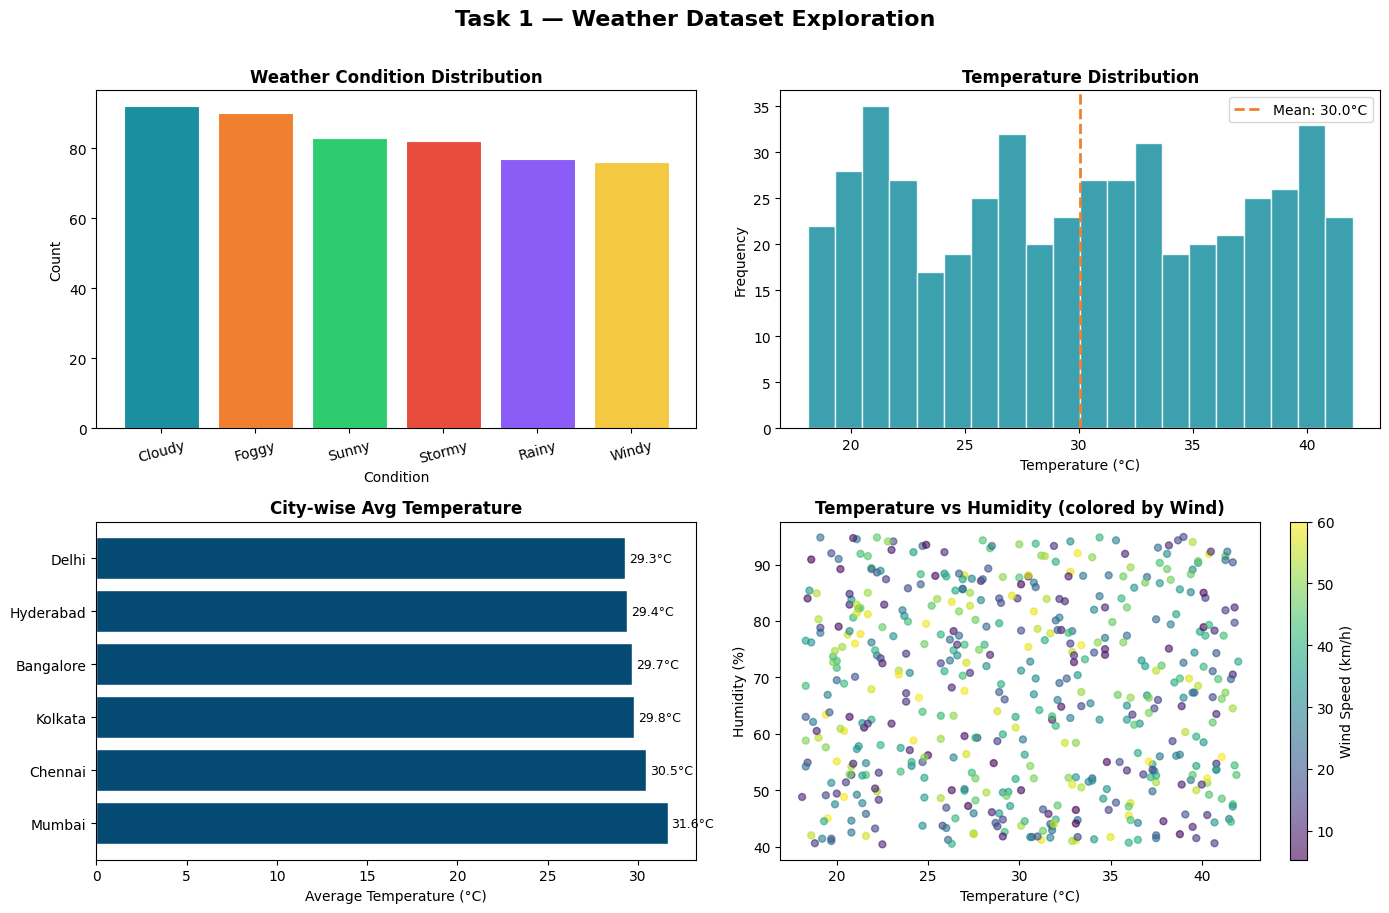

✅ Task 1 Complete — Dataset loaded and visualized!


In [5]:
# ─── 1C. Dataset Visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Task 1 — Weather Dataset Exploration', fontsize=16, fontweight='bold', y=1.01)

# Plot 1: Weather condition distribution
cond_counts = weather_df['condition'].value_counts()
colors = ['#1A8FA0','#F08030','#2ECC71','#E74C3C','#8B5CF6','#F5C842']
axes[0,0].bar(cond_counts.index, cond_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0,0].set_title('Weather Condition Distribution', fontweight='bold')
axes[0,0].set_xlabel('Condition')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=15)

# Plot 2: Temperature distribution
axes[0,1].hist(weather_df['temperature'], bins=20, color='#1A8FA0', edgecolor='white', alpha=0.85)
axes[0,1].axvline(weather_df['temperature'].mean(), color='#F08030', linestyle='--', linewidth=2, label=f'Mean: {weather_df["temperature"].mean():.1f}°C')
axes[0,1].set_title('Temperature Distribution', fontweight='bold')
axes[0,1].set_xlabel('Temperature (°C)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# Plot 3: City-wise average temperature
city_temp = weather_df.groupby('city')['temperature'].mean().sort_values(ascending=False)
axes[1,0].barh(city_temp.index, city_temp.values, color='#054A72', edgecolor='white')
axes[1,0].set_title('City-wise Avg Temperature', fontweight='bold')
axes[1,0].set_xlabel('Average Temperature (°C)')
for i, v in enumerate(city_temp.values):
    axes[1,0].text(v + 0.2, i, f'{v:.1f}°C', va='center', fontsize=9)

# Plot 4: Humidity vs Temperature scatter
scatter = axes[1,1].scatter(
    weather_df['temperature'], weather_df['humidity'],
    c=weather_df['wind_speed'], cmap='viridis', alpha=0.6, s=25
)
plt.colorbar(scatter, ax=axes[1,1], label='Wind Speed (km/h)')
axes[1,1].set_title('Temperature vs Humidity (colored by Wind)', fontweight='bold')
axes[1,1].set_xlabel('Temperature (°C)')
axes[1,1].set_ylabel('Humidity (%)')

plt.tight_layout()
plt.savefig('task1_dataset_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Task 1 Complete — Dataset loaded and visualized!')

---
## 🔤 Task 2 — NLP Processing
> Pick a random sentence → Tokenization → Stemming → Lemmatization → Stop Word Removal

In [6]:
# ─── 2A. Pick a Random Sentence ──────────────────────────────────────────────
random.seed(10)
sample_sentence = random.choice(review_sentences)

print('='*70)
print('TASK 2 — NLP PROCESSING')
print('='*70)
print(f'\n📌 Random Sentence Selected:')
print(f'   "{sample_sentence}"')
print(f'\n   Total characters : {len(sample_sentence)}')
print(f'   Total words       : {len(sample_sentence.split())}')

TASK 2 — NLP PROCESSING

📌 Random Sentence Selected:
   "Coastal Karnataka and Goa receive extremely heavy rainfall during monsoon season."

   Total characters : 81
   Total words       : 11


In [7]:
# ─── 2B. Tokenization ────────────────────────────────────────────────────────
# Word tokenization
word_tokens = word_tokenize(sample_sentence)

# Sentence tokenization (on full review text)
full_text   = ' '.join(review_sentences)
sent_tokens = sent_tokenize(full_text)

print('─'*60)
print('STEP 1 — TOKENIZATION')
print('─'*60)
print(f'\nOriginal Sentence:')
print(f'  "{sample_sentence}"')
print(f'\nWord Tokens ({len(word_tokens)} tokens):')
print(f'  {word_tokens}')
print(f'\nPunctuation / Special tokens identified:')
punct = [t for t in word_tokens if not t.isalpha()]
print(f'  {punct}')

────────────────────────────────────────────────────────────
STEP 1 — TOKENIZATION
────────────────────────────────────────────────────────────

Original Sentence:
  "Coastal Karnataka and Goa receive extremely heavy rainfall during monsoon season."

Word Tokens (12 tokens):
  ['Coastal', 'Karnataka', 'and', 'Goa', 'receive', 'extremely', 'heavy', 'rainfall', 'during', 'monsoon', 'season', '.']

Punctuation / Special tokens identified:
  ['.']


In [8]:
# ─── 2C. Stemming ────────────────────────────────────────────────────────────
porter   = PorterStemmer()
snowball = SnowballStemmer('english')

# Apply stemming — only on alphabetic tokens
alpha_tokens    = [t for t in word_tokens if t.isalpha()]
porter_stemmed  = [porter.stem(t)   for t in alpha_tokens]
snowball_stemmed= [snowball.stem(t) for t in alpha_tokens]

print('─'*60)
print('STEP 2 — STEMMING')
print('─'*60)
print(f'\nComparison Table (Original → Porter → Snowball):')
print(f'  {"Word":<20} {"Porter":<20} {"Snowball":<20}')
print(f'  {"-"*58}')
for orig, port, snow in zip(alpha_tokens, porter_stemmed, snowball_stemmed):
    changed = '✂' if (port != orig.lower() or snow != orig.lower()) else '  '
    print(f'  {changed} {orig:<18} {port:<20} {snow:<20}')

print(f'\nPorter Stemmed Result:')
print(f'  {porter_stemmed}')

────────────────────────────────────────────────────────────
STEP 2 — STEMMING
────────────────────────────────────────────────────────────

Comparison Table (Original → Porter → Snowball):
  Word                 Porter               Snowball            
  ----------------------------------------------------------
     Coastal            coastal              coastal             
     Karnataka          karnataka            karnataka           
     and                and                  and                 
     Goa                goa                  goa                 
  ✂ receive            receiv               receiv              
  ✂ extremely          extrem               extrem              
  ✂ heavy              heavi                heavi               
  ✂ rainfall           rainfal              rainfal             
  ✂ during             dure                 dure                
     monsoon            monsoon              monsoon             
     season             seaso

In [9]:
# ─── 2D. Lemmatization ───────────────────────────────────────────────────────
lemmatizer = WordNetLemmatizer()

lemmatized = [lemmatizer.lemmatize(t.lower()) for t in alpha_tokens]

# Show difference between stemming and lemmatization
print('─'*60)
print('STEP 3 — LEMMATIZATION')
print('─'*60)
print(f'\nKey Difference: Lemmatization returns real dictionary words')
print(f'                Stemming may return non-words (e.g. "rainfal")\n')
print(f'  {"Word":<20} {"Stemmed":<20} {"Lemmatized":<20}')
print(f'  {"-"*58}')
for orig, stem, lem in zip(alpha_tokens, porter_stemmed, lemmatized):
    marker = '★' if stem != lem else ' '
    print(f'  {marker} {orig:<18} {stem:<20} {lem:<20}')

print(f'\nLemmatized Tokens:')
print(f'  {lemmatized}')

────────────────────────────────────────────────────────────
STEP 3 — LEMMATIZATION
────────────────────────────────────────────────────────────

Key Difference: Lemmatization returns real dictionary words
                Stemming may return non-words (e.g. "rainfal")

  Word                 Stemmed              Lemmatized          
  ----------------------------------------------------------
    Coastal            coastal              coastal             
    Karnataka          karnataka            karnataka           
    and                and                  and                 
    Goa                goa                  goa                 
  ★ receive            receiv               receive             
  ★ extremely          extrem               extremely           
  ★ heavy              heavi                heavy               
  ★ rainfall           rainfal              rainfall            
  ★ during             dure                 during              
    monsoon        

In [10]:
# ─── 2E. Stop Word Removal ───────────────────────────────────────────────────
stop_words   = set(stopwords.words('english'))
all_tokens   = word_tokenize(sample_sentence.lower())
stop_found   = [t for t in all_tokens if t in stop_words]
clean_tokens = [t for t in all_tokens if t.isalpha() and t not in stop_words]

print('─'*60)
print('STEP 4 — STOP WORD REMOVAL')
print('─'*60)
print(f'\nTotal NLTK English stop words : {len(stop_words)}')
print(f'\nOriginal tokens   ({len(all_tokens):>2})  : {all_tokens}')
print(f'\nStop words found  ({len(stop_found):>2})  : {stop_found}')
print(f'\nClean tokens      ({len(clean_tokens):>2})  : {clean_tokens}')
print(f'\nNoise reduction   : {(len(stop_found)/len(all_tokens)*100):.1f}% tokens removed')

────────────────────────────────────────────────────────────
STEP 4 — STOP WORD REMOVAL
────────────────────────────────────────────────────────────

Total NLTK English stop words : 198

Original tokens   (12)  : ['coastal', 'karnataka', 'and', 'goa', 'receive', 'extremely', 'heavy', 'rainfall', 'during', 'monsoon', 'season', '.']

Stop words found  ( 2)  : ['and', 'during']

Clean tokens      ( 9)  : ['coastal', 'karnataka', 'goa', 'receive', 'extremely', 'heavy', 'rainfall', 'monsoon', 'season']

Noise reduction   : 16.7% tokens removed


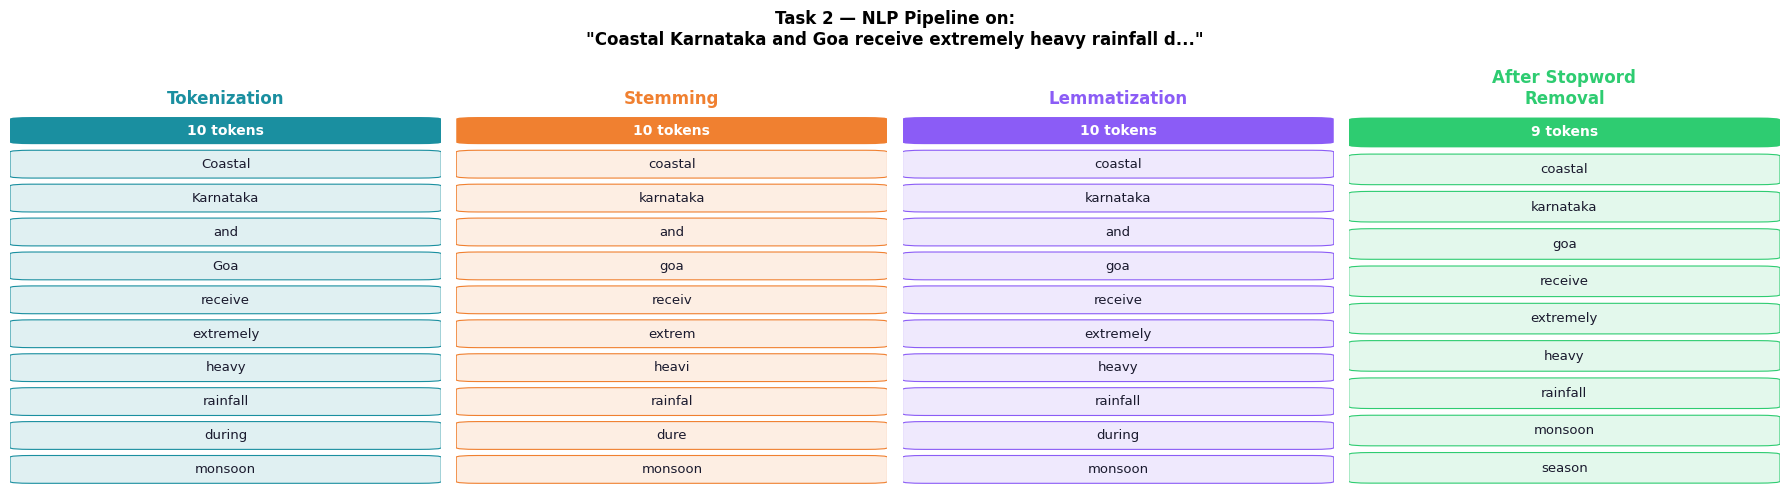

✅ Task 2 Complete!


In [11]:
# ─── 2F. NLP Pipeline Summary Visualization ──────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'Task 2 — NLP Pipeline on:\n"{sample_sentence[:60]}..."',
             fontsize=12, fontweight='bold')

steps = [
    ('Tokenization', word_tokens[:10], '#1A8FA0'),
    ('Stemming',     porter_stemmed[:10], '#F08030'),
    ('Lemmatization',lemmatized[:10], '#8B5CF6'),
    ('After Stopword\nRemoval', clean_tokens[:10], '#2ECC71'),
]

for ax, (title, tokens, color) in zip(axes, steps):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, len(tokens) + 1)
    ax.axis('off')
    ax.set_title(title, fontweight='bold', color=color, fontsize=12)
    # Draw header
    ax.add_patch(FancyBboxPatch((0.05, len(tokens)+0.1), 0.9, 0.7,
                                boxstyle='round,pad=0.05', facecolor=color, edgecolor='none'))
    ax.text(0.5, len(tokens)+0.45, f'{len(tokens)} tokens', ha='center', va='center',
            color='white', fontsize=10, fontweight='bold')
    for i, tok in enumerate(reversed(tokens)):
        ax.add_patch(FancyBboxPatch((0.05, i+0.1), 0.9, 0.72,
                                    boxstyle='round,pad=0.05',
                                    facecolor=color + '22' if len(color)==7 else color,
                                    edgecolor=color, linewidth=0.8))
        ax.text(0.5, i+0.45, tok, ha='center', va='center', fontsize=9.5, color='#1a1a2e')

plt.tight_layout()
plt.savefig('task2_nlp_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Task 2 Complete!')

---
## 🏷 Task 3 — Vocabulary & Matching
> Named Entity Recognition · Noun Chunks · Display Diagram · Pattern Matching

In [12]:
# ─── 3A. Pick Random Sentence & Run spaCy ─────────────────────────────────────
random.seed(7)
task3_sentence = random.choice(review_sentences)

doc = nlp(task3_sentence)

print('='*70)
print('TASK 3 — VOCABULARY & MATCHING')
print('='*70)
print(f'\n📌 Selected Sentence:')
print(f'   "{task3_sentence}"')

TASK 3 — VOCABULARY & MATCHING

📌 Selected Sentence:
   "Light drizzle expected in the afternoon but overall a pleasant day in Kolkata."


In [13]:
# ─── 3B. Named Entity Recognition ────────────────────────────────────────────
print('─'*60)
print('STEP 1 — NAMED ENTITY RECOGNITION (NER)')
print('─'*60)

if doc.ents:
    print(f'\n  {"Entity Text":<25} {"Label":<15} {"Description"}')
    print(f'  {"-"*60}')
    for ent in doc.ents:
        desc = spacy.explain(ent.label_) or 'N/A'
        print(f'  {ent.text:<25} {ent.label_:<15} {desc}')
else:
    print('  No named entities found in this sentence.')
    print('  Trying a richer sentence...')
    task3_sentence = "Severe flooding is expected in Mumbai and Delhi due to heavy monsoon rains on Tuesday morning."
    doc = nlp(task3_sentence)
    print(f'\n  Using: "{task3_sentence}"\n')
    for ent in doc.ents:
        desc = spacy.explain(ent.label_) or 'N/A'
        print(f'  {ent.text:<25} {ent.label_:<15} {desc}')

────────────────────────────────────────────────────────────
STEP 1 — NAMED ENTITY RECOGNITION (NER)
────────────────────────────────────────────────────────────

  Entity Text               Label           Description
  ------------------------------------------------------------
  a pleasant day            DATE            Absolute or relative dates or periods
  Kolkata                   GPE             Countries, cities, states


In [14]:
# ─── 3C. Noun Chunks ─────────────────────────────────────────────────────────
print('─'*60)
print('STEP 2 — NOUN CHUNKS')
print('─'*60)
print(f'\n  {"#":<4} {"Noun Chunk":<30} {"Root":<15} {"Root Dep"}')
print(f'  {"-"*60}')
for i, chunk in enumerate(doc.noun_chunks, 1):
    print(f'  {i:<4} {chunk.text:<30} {chunk.root.text:<15} {chunk.root.dep_}')

────────────────────────────────────────────────────────────
STEP 2 — NOUN CHUNKS
────────────────────────────────────────────────────────────

  #    Noun Chunk                     Root            Root Dep
  ------------------------------------------------------------
  1    Light drizzle                  drizzle         ROOT
  2    the afternoon                  afternoon       pobj
  3    overall a pleasant day         day             conj
  4    Kolkata                        Kolkata         pobj


In [15]:
# ─── 3D. Display Diagram (NER Visualization) ──────────────────────────────────
print('─'*60)
print('STEP 3 — ENTITY DISPLAY DIAGRAM (displaCy)')
print('─'*60)

# displaCy rendering in Colab
from IPython.display import display as ipy_display, HTML

# Custom colors for entity labels
colors = {
    'GPE'  : '#1A8FA0',
    'TIME' : '#F08030',
    'DATE' : '#F08030',
    'ORG'  : '#8B5CF6',
    'PERSON':'#2ECC71',
    'LOC'  : '#1A8FA0',
    'EVENT': '#E74C3C',
    'NORP' : '#F5C842',
}
options = {'colors': colors, 'ents': None}

html = displacy.render(doc, style='ent', options=options, page=False, jupyter=False)
# Wrap in styled div
styled_html = f"""
<div style="font-family: Arial; font-size: 15px; padding: 15px;
            background: #f8f9fa; border-radius: 8px; border: 1px solid #dee2e6;">
  <strong>NER Output (displaCy):</strong><br><br>
  {html}
</div>
"""
ipy_display(HTML(styled_html))

────────────────────────────────────────────────────────────
STEP 3 — ENTITY DISPLAY DIAGRAM (displaCy)
────────────────────────────────────────────────────────────


In [16]:
# ─── 3E. Dependency Parse Diagram ─────────────────────────────────────────────
print('─'*60)
print('STEP 4 — DEPENDENCY PARSE TREE (displaCy dep)')
print('─'*60)

dep_html = displacy.render(doc, style='dep', options={'compact': True, 'distance': 100},
                           page=False, jupyter=False)
dep_styled = f"""
<div style="overflow-x: auto; padding: 10px; background: #f8f9fa;
            border-radius: 8px; border: 1px solid #dee2e6;">
  <strong>Dependency Tree:</strong><br><br>
  {dep_html}
</div>
"""
ipy_display(HTML(dep_styled))

────────────────────────────────────────────────────────────
STEP 4 — DEPENDENCY PARSE TREE (displaCy dep)
────────────────────────────────────────────────────────────


In [17]:
# ─── 3F. Pattern Matching with spaCy Matcher ──────────────────────────────────
print('─'*60)
print('STEP 5 — PATTERN MATCHING (spaCy Matcher)')
print('─'*60)

matcher = Matcher(nlp.vocab)

# Define weather-specific patterns
patterns = {
    'RAIN_PATTERN'    : [[{'LOWER': 'rain'}], [{'LOWER': 'rainfall'}], [{'LOWER': 'rains'}]],
    'WEATHER_EVENT'   : [[{'LOWER': {'IN': ['flood', 'flooding', 'storm', 'cyclone', 'heatwave', 'snowfall']}}]],
    'FORECAST_WORD'   : [[{'LOWER': {'IN': ['expected', 'forecast', 'predicted', 'likely']}}]],
    'LOCATION_CONTEXT': [[{'ENT_TYPE': 'GPE'}]],
    'TIME_CONTEXT'    : [[{'ENT_TYPE': {'IN': ['TIME','DATE']}}]],
    'SEVERITY_WORD'   : [[{'LOWER': {'IN': ['heavy', 'severe', 'strong', 'extreme', 'catastrophic', 'violent']}}]],
}

for pattern_name, pattern_list in patterns.items():
    matcher.add(pattern_name, pattern_list)

# Test on all sentences
print('\nPattern matches across dataset sentences:\n')
print(f'  {"Pattern Name":<22} {"Matched Text":<25} {"Sentence (truncated)"}')
print(f'  {"-"*80}')

found_matches = []
for sentence in review_sentences:
    d = nlp(sentence)
    matches = matcher(d)
    for match_id, start, end in matches:
        label = nlp.vocab.strings[match_id]
        span  = d[start:end].text
        found_matches.append({'pattern': label, 'match': span, 'sentence': sentence[:55]+'...'})

match_df = pd.DataFrame(found_matches)
if not match_df.empty:
    # Show top unique matches per pattern
    for pattern in match_df['pattern'].unique():
        subset = match_df[match_df['pattern'] == pattern].drop_duplicates('match')
        for _, row in subset.head(3).iterrows():
            print(f'  {row["pattern"]:<22} {row["match"]:<25} {row["sentence"]}')

print(f'\nTotal matches found: {len(found_matches)}')
print('✅ Task 3 Complete!')

────────────────────────────────────────────────────────────
STEP 5 — PATTERN MATCHING (spaCy Matcher)
────────────────────────────────────────────────────────────

Pattern matches across dataset sentences:

  Pattern Name           Matched Text              Sentence (truncated)
  --------------------------------------------------------------------------------
  SEVERITY_WORD          heavy                     The heavy rainfall and strong winds are expected in Che...
  SEVERITY_WORD          strong                    The heavy rainfall and strong winds are expected in Che...
  SEVERITY_WORD          Severe                    Severe flooding is expected in Mumbai and Delhi due to ...
  RAIN_PATTERN           rainfall                  The heavy rainfall and strong winds are expected in Che...
  RAIN_PATTERN           rains                     Severe flooding is expected in Mumbai and Delhi due to ...
  RAIN_PATTERN           rain                      Weather forecast shows partly cloudy

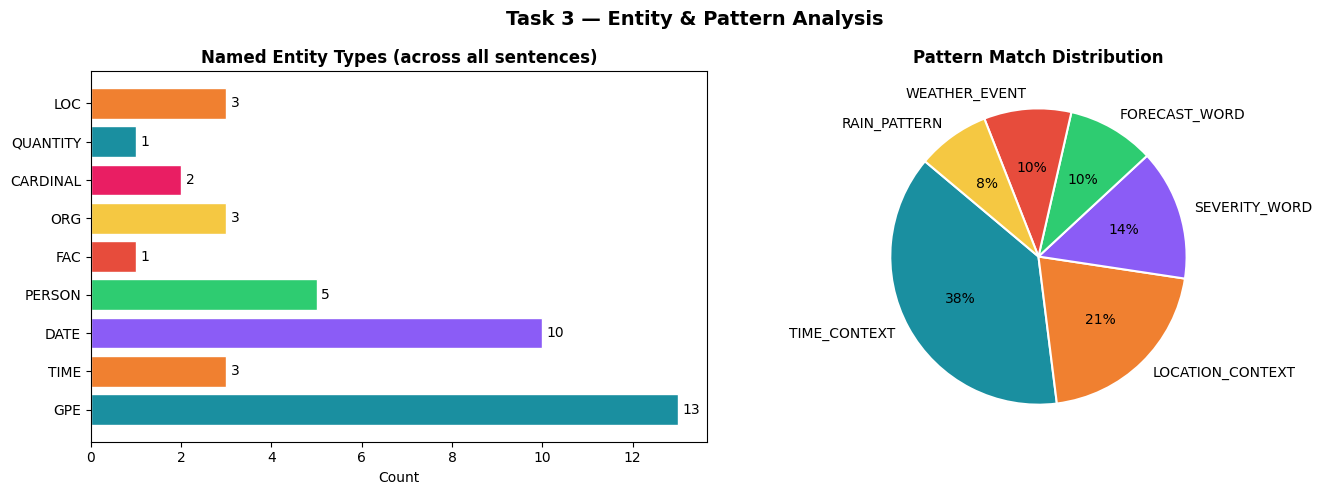

In [18]:
# ─── 3G. NER Visualization Chart ─────────────────────────────────────────────
# Count entity types across all sentences
entity_counts = {}
for sentence in review_sentences:
    d = nlp(sentence)
    for ent in d.ents:
        entity_counts[ent.label_] = entity_counts.get(ent.label_, 0) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 3 — Entity & Pattern Analysis', fontsize=14, fontweight='bold')

# Entity type frequency
ent_labels = list(entity_counts.keys())
ent_vals   = list(entity_counts.values())
ent_colors = ['#1A8FA0','#F08030','#8B5CF6','#2ECC71','#E74C3C','#F5C842','#E91E63']
ax1.barh(ent_labels, ent_vals, color=ent_colors[:len(ent_labels)], edgecolor='white')
ax1.set_title('Named Entity Types (across all sentences)', fontweight='bold')
ax1.set_xlabel('Count')
for i, v in enumerate(ent_vals):
    ax1.text(v + 0.1, i, str(v), va='center', fontsize=10)

# Pattern match frequency
if not match_df.empty:
    pattern_freq = match_df['pattern'].value_counts()
    ax2.pie(pattern_freq.values, labels=pattern_freq.index,
            colors=ent_colors[:len(pattern_freq)],
            autopct='%1.0f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax2.set_title('Pattern Match Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('task3_ner_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🤖 Task 4 — Text Classification (Logistic Regression)
> Train/test split → TF-IDF → Logistic Regression → Accuracy + Confusion Matrix

In [19]:
# ─── 4A. Prepare Classification Dataset ──────────────────────────────────────
# Build labeled dataset from intents
texts, labels = [], []
for intent in intents_data['intents']:
    for pattern in intent['patterns']:
        texts.append(pattern)
        labels.append(intent['tag'])

# Augment with more examples for better training
augmented = {
    'greet'            : ['Hey there', 'What is up', 'Good afternoon', 'Namaste', 'Greetings'],
    'ask_temperature'  : ['Current temp outside', 'Is it hot today', 'Degree celsius now',
                          'What temperature is it', 'How many degrees is it'],
    'ask_rain'         : ['Chance of precipitation', 'Will there be showers', 'Bring umbrella today',
                          'Any rain expected', 'Is it drizzling'],
    'ask_wind_speed'   : ['Gust forecast', 'Storm winds today', 'Wind advisory',
                          'Breezy today', 'Any strong winds expected'],
    'ask_forecast'     : ['What to expect weather wise', 'Future weather outlook',
                          'Give weather update', 'Weather next 7 days', 'Detailed forecast'],
}
for label_key, extra_texts in augmented.items():
    for t in extra_texts:
        texts.append(t)
        labels.append(label_key)

print('='*60)
print('TASK 4 — TEXT CLASSIFICATION')
print('='*60)
print(f'\nDataset Summary:')
print(f'  Total samples : {len(texts)}')

label_counts = {}
for l in labels:
    label_counts[l] = label_counts.get(l, 0) + 1
for lbl, cnt in label_counts.items():
    print(f'  {lbl:<22} : {cnt} samples')

TASK 4 — TEXT CLASSIFICATION

Dataset Summary:
  Total samples : 54
  greet                  : 11 samples
  ask_temperature        : 11 samples
  ask_rain               : 11 samples
  ask_wind_speed         : 10 samples
  ask_forecast           : 11 samples


In [20]:
# ─── 4B. Train / Test Split ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.25, random_state=42, stratify=labels
)
print(f'\nTrain / Test Split:')
print(f'  Training samples : {len(X_train)}')
print(f'  Test samples     : {len(X_test)}')


Train / Test Split:
  Training samples : 40
  Test samples     : 14


In [21]:
# ─── 4C. TF-IDF + Logistic Regression Pipeline ───────────────────────────────
clf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),       # unigrams + bigrams
        max_features=5000,
        sublinear_tf=True         # log normalization
    )),
    ('clf', LogisticRegression(
        max_iter=500,
        random_state=42,
        C=1.0,                    # regularization
        solver='lbfgs',
        multi_class='multinomial'
    ))
])

# Train
clf_pipeline.fit(X_train, y_train)

# Predict
y_pred       = clf_pipeline.predict(X_test)
train_acc    = clf_pipeline.score(X_train, y_train)
test_acc     = accuracy_score(y_test, y_pred)

print('─'*60)
print('MODEL RESULTS')
print('─'*60)
print(f'\n  Training Accuracy : {train_acc*100:.2f}%')
print(f'  Test Accuracy     : {test_acc*100:.2f}%')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

────────────────────────────────────────────────────────────
MODEL RESULTS
────────────────────────────────────────────────────────────

  Training Accuracy : 100.00%
  Test Accuracy     : 85.71%

Classification Report:
                 precision    recall  f1-score   support

   ask_forecast       1.00      1.00      1.00         3
       ask_rain       0.75      1.00      0.86         3
ask_temperature       0.75      1.00      0.86         3
 ask_wind_speed       0.00      0.00      0.00         2
          greet       1.00      1.00      1.00         3

       accuracy                           0.86        14
      macro avg       0.70      0.80      0.74        14
   weighted avg       0.75      0.86      0.80        14



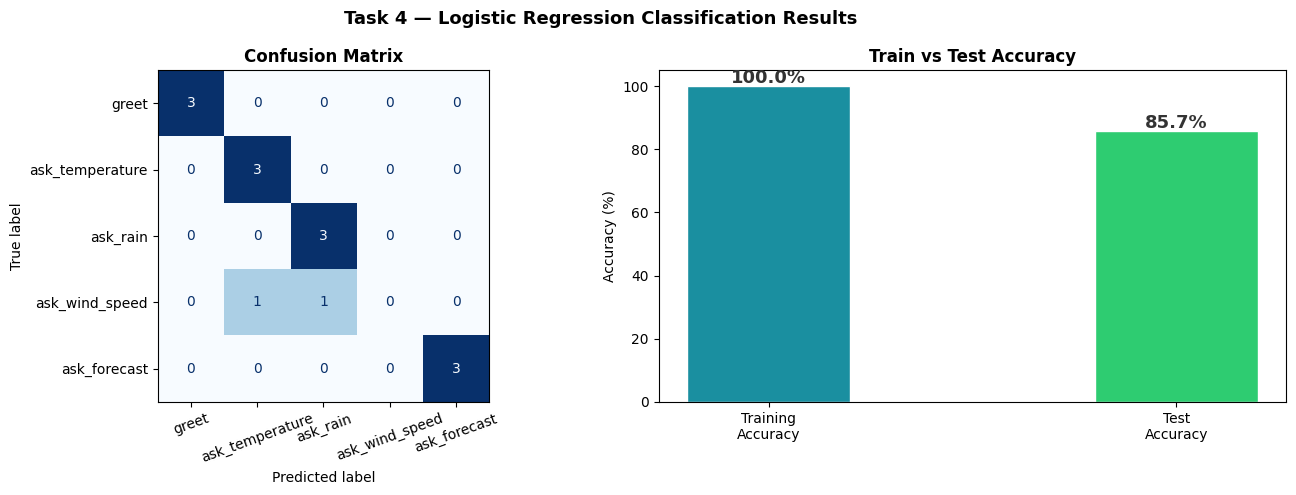

✅ Task 4 Complete!


In [22]:
# ─── 4D. Confusion Matrix + Accuracy Chart ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 4 — Logistic Regression Classification Results', fontsize=13, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=list(label_counts.keys()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label_counts.keys()))
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# Accuracy comparison bar
metrics = ['Training\nAccuracy', 'Test\nAccuracy']
values  = [train_acc * 100, test_acc * 100]
bar_colors = ['#1A8FA0', '#2ECC71']
bars = axes[1].bar(metrics, values, color=bar_colors, width=0.4, edgecolor='white')
axes[1].set_ylim(0, 105)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Train vs Test Accuracy', fontweight='bold')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold', color='#333')

plt.tight_layout()
plt.savefig('task4_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Task 4 Complete!')

In [23]:
# ─── 4E. Test the classifier with custom inputs ───────────────────────────────
test_queries = [
    "Will it rain in Chennai tomorrow?",
    "What is the temperature today?",
    "Hello, good morning!",
    "Give me the weekly weather forecast",
    "How strong are the winds?",
]

print('─'*60)
print('LIVE INTENT PREDICTION')
print('─'*60)
print(f'\n  {"Query":<45} {"Predicted Intent"}')
print(f'  {"-"*65}')
for q in test_queries:
    pred  = clf_pipeline.predict([q])[0]
    proba = clf_pipeline.predict_proba([q]).max()
    print(f'  {q:<45} {pred}  ({proba*100:.0f}% confident)')

────────────────────────────────────────────────────────────
LIVE INTENT PREDICTION
────────────────────────────────────────────────────────────

  Query                                         Predicted Intent
  -----------------------------------------------------------------
  Will it rain in Chennai tomorrow?             ask_rain  (32% confident)
  What is the temperature today?                ask_temperature  (31% confident)
  Hello, good morning!                          greet  (46% confident)
  Give me the weekly weather forecast           ask_forecast  (45% confident)
  How strong are the winds?                     ask_wind_speed  (27% confident)


---
## 💬 Task 5 — Sentiment Analysis
> Analyse sentiment (positive/neutral/negative) across the full weather dataset

In [24]:
# ─── 5A. Sentiment Analysis with TextBlob ─────────────────────────────────────
def get_sentiment_label(polarity):
    if polarity >  0.1: return 'positive'
    elif polarity < -0.1: return 'negative'
    else: return 'neutral'

def analyze_sentiment(text):
    blob = TextBlob(text)
    return {
        'polarity'     : round(blob.sentiment.polarity,     3),
        'subjectivity' : round(blob.sentiment.subjectivity, 3),
        'label'        : get_sentiment_label(blob.sentiment.polarity)
    }

print('='*70)
print('TASK 5 — SENTIMENT ANALYSIS')
print('='*70)

# Analyse all review sentences
results = []
for sentence in review_sentences:
    s = analyze_sentiment(sentence)
    s['text'] = sentence
    results.append(s)

result_df = pd.DataFrame(results)

print(f'\nSentiment analysis on {len(result_df)} weather sentences:')
print(f'\n  {"Polarity":<12} {"Subjectivity":<15} {"Label":<12} {"Sentence (truncated)"}')
print(f'  {"-"*80}')
for _, row in result_df.iterrows():
    indicator = '🟢' if row['label']=='positive' else ('🔴' if row['label']=='negative' else '🟡')
    print(f'  {row["polarity"]:>+8.3f}     {row["subjectivity"]:>8.3f}     {indicator} {row["label"]:<10} {row["text"][:45]}...')

TASK 5 — SENTIMENT ANALYSIS

Sentiment analysis on 20 weather sentences:

  Polarity     Subjectivity    Label        Sentence (truncated)
  --------------------------------------------------------------------------------
    +0.044        0.544     🟡 neutral    The heavy rainfall and strong winds are expec...
    -0.142        0.425     🔴 negative   Severe flooding is expected in Mumbai and Del...
    +0.533        0.733     🟢 positive   Today the weather in Bangalore is sunny and p...
    +0.000        0.000     🟡 neutral    Cyclone warning issued for coastal areas of T...
    +0.375        0.875     🟢 positive   Temperature in Delhi drops significantly duri...
    -0.100        0.250     🟡 neutral    The India Meteorological Department predicts ...
    +0.167        0.567     🟢 positive   Strong gusty winds and thunderstorms are expe...
    +0.400        0.700     🟢 positive   Weather forecast shows partly cloudy skies wi...
    +0.867        0.867     🟢 positive   The sunny warm we

In [25]:
# ─── 5B. Sentiment on Labeled Dataset + Accuracy ─────────────────────────────
sentiment_df['predicted']    = sentiment_df['text'].apply(
    lambda x: analyze_sentiment(x)['label']
)
sentiment_df['polarity']     = sentiment_df['text'].apply(
    lambda x: analyze_sentiment(x)['polarity']
)
sentiment_df['subjectivity'] = sentiment_df['text'].apply(
    lambda x: analyze_sentiment(x)['subjectivity']
)

sent_accuracy = accuracy_score(sentiment_df['sentiment'], sentiment_df['predicted'])

print('─'*60)
print('SENTIMENT ACCURACY ON LABELED DATASET')
print('─'*60)
print(f'\n  Sentiment Accuracy : {sent_accuracy*100:.2f}%')
print(f'\n  Prediction Results:')
print(f'  {"Text (truncated)":<50} {"Actual":<12} {"Predicted":<12} {"Match"}')
print(f'  {"-"*90}')
for _, row in sentiment_df.iterrows():
    match = '✅' if row['sentiment'] == row['predicted'] else '❌'
    print(f'  {row["text"][:48]:<50} {row["sentiment"]:<12} {row["predicted"]:<12} {match}')

────────────────────────────────────────────────────────────
SENTIMENT ACCURACY ON LABELED DATASET
────────────────────────────────────────────────────────────

  Sentiment Accuracy : 73.33%

  Prediction Results:
  Text (truncated)                                   Actual       Predicted    Match
  ------------------------------------------------------------------------------------------
  The sunny warm weather today is absolutely wonde   positive     positive     ✅
  Beautiful clear skies and gentle breeze make tod   positive     positive     ✅
  Lovely weather for a morning walk in the park.     positive     positive     ✅
  Finally the rains have brought relief from the t   positive     negative     ❌
  The cool pleasant weather is a welcome change.     positive     positive     ✅
  Catastrophic flooding has destroyed homes and cr   negative     neutral      ❌
  Violent cyclone causes widespread destruction an   negative     negative     ✅
  Severe drought conditions are devastati

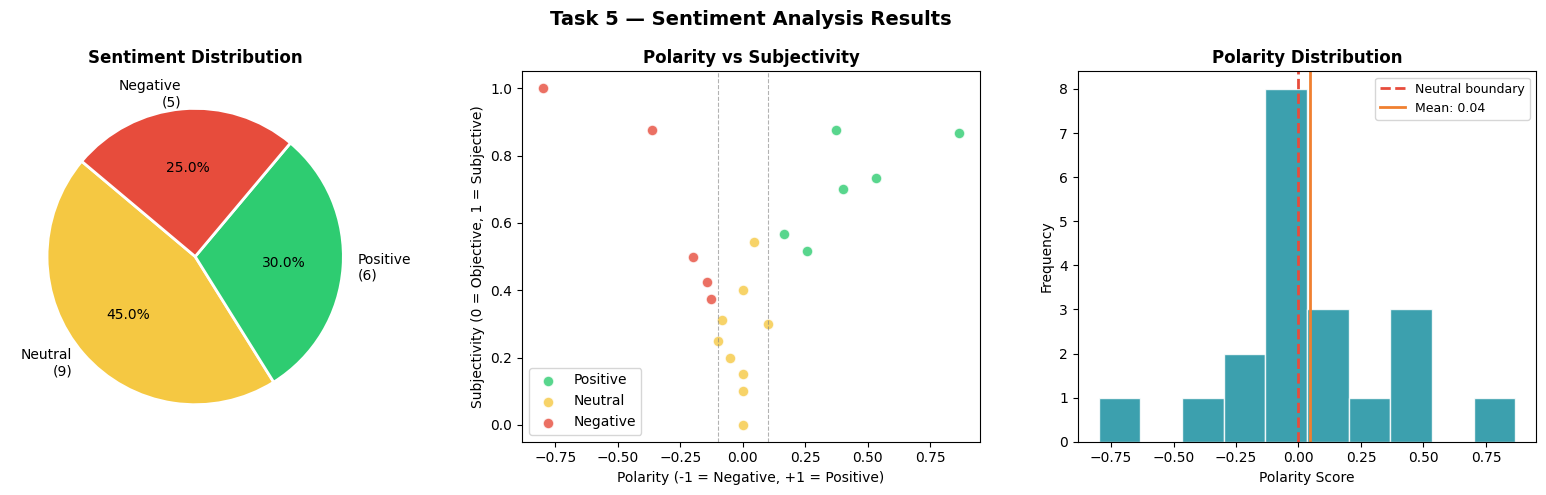

✅ Task 5 Complete!


In [26]:
# ─── 5C. Sentiment Visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Task 5 — Sentiment Analysis Results', fontsize=14, fontweight='bold')

sent_colors = {'positive': '#2ECC71', 'neutral': '#F5C842', 'negative': '#E74C3C'}

# 1. Sentiment distribution pie
sent_counts = result_df['label'].value_counts()
axes[0].pie(
    sent_counts.values,
    labels=[f'{l.capitalize()}\n({v})' for l, v in sent_counts.items()],
    colors=[sent_colors[l] for l in sent_counts.index],
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Sentiment Distribution', fontweight='bold')

# 2. Polarity scatter
for label, color in sent_colors.items():
    subset = result_df[result_df['label'] == label]
    axes[1].scatter(subset['polarity'], subset['subjectivity'],
                    c=color, label=label.capitalize(), s=60, alpha=0.8, edgecolors='white')
axes[1].axvline(x=0.1,  color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
axes[1].axvline(x=-0.1, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
axes[1].set_xlabel('Polarity (-1 = Negative, +1 = Positive)')
axes[1].set_ylabel('Subjectivity (0 = Objective, 1 = Subjective)')
axes[1].set_title('Polarity vs Subjectivity', fontweight='bold')
axes[1].legend()

# 3. Polarity histogram
axes[2].hist(result_df['polarity'], bins=10, color='#1A8FA0', edgecolor='white', alpha=0.85)
axes[2].axvline(x=0, color='#E74C3C', linestyle='--', linewidth=2, label='Neutral boundary')
axes[2].axvline(x=result_df['polarity'].mean(), color='#F08030', linestyle='-',
                linewidth=2, label=f'Mean: {result_df["polarity"].mean():.2f}')
axes[2].set_xlabel('Polarity Score')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Polarity Distribution', fontweight='bold')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('task5_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Task 5 Complete!')

---
## 🌤 Task 6 — Building the Weather Chatbot
> Integrate all pipelines: NLP preprocessing → NER → Intent Classification → Response Generation

In [27]:
# ─── 6A. Preprocessing Function ───────────────────────────────────────────────
def preprocess_query(text):
    """Clean and normalize user input."""
    text   = text.lower().strip()
    text   = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # remove punctuation
    tokens = word_tokenize(text)
    lemma  = WordNetLemmatizer()
    sw     = set(stopwords.words('english'))
    # Keep stopwords for intent classification (they carry meaning in questions)
    clean  = [lemma.lemmatize(t) for t in tokens if t.isalpha()]
    return ' '.join(clean)

print('='*70)
print('TASK 6 — CHATBOT PIPELINE')
print('='*70)
print('\n  preprocess_query() function defined ✅')

TASK 6 — CHATBOT PIPELINE

  preprocess_query() function defined ✅


In [28]:
# ─── 6B. Entity Extraction Function ──────────────────────────────────────────
def extract_entities(text):
    """Extract location, time, and weather entities from user query."""
    doc      = nlp(text)
    entities = {'city': None, 'time': None, 'date': None, 'weather_term': None}

    for ent in doc.ents:
        if ent.label_ in ('GPE', 'LOC') and not entities['city']:
            entities['city'] = ent.text
        elif ent.label_ == 'TIME' and not entities['time']:
            entities['time'] = ent.text
        elif ent.label_ == 'DATE' and not entities['date']:
            entities['date'] = ent.text

    # Weather keyword matching
    weather_keywords = ['rain', 'snow', 'wind', 'storm', 'fog', 'sunny',
                        'hot', 'cold', 'humid', 'temperature', 'flood', 'cyclone']
    for token in doc:
        if token.lemma_.lower() in weather_keywords:
            entities['weather_term'] = token.text
            break

    return entities

print('  extract_entities() function defined ✅')

  extract_entities() function defined ✅


In [29]:
# ─── 6C. Mock Weather API Function ────────────────────────────────────────────
# In production: replace with real OpenWeatherMap API call
# import requests
# API_KEY = 'your_api_key_here'
# url = f'http://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric'
# response = requests.get(url).json()

def get_mock_weather(city='Unknown'):
    """Returns simulated weather data for demo purposes."""
    mock_data = {
        'Chennai'  : {'temp': 34, 'condition': 'Partly Cloudy', 'humidity': 72, 'wind': 18, 'rain_chance': 45},
        'Mumbai'   : {'temp': 29, 'condition': 'Monsoon Showers', 'humidity': 88, 'wind': 25, 'rain_chance': 80},
        'Delhi'    : {'temp': 38, 'condition': 'Haze', 'humidity': 48, 'wind': 12, 'rain_chance': 10},
        'Bangalore': {'temp': 24, 'condition': 'Pleasant & Breezy', 'humidity': 62, 'wind': 15, 'rain_chance': 20},
        'Kolkata'  : {'temp': 31, 'condition': 'Humid & Cloudy', 'humidity': 80, 'wind': 14, 'rain_chance': 55},
    }
    # Default for unknown cities
    return mock_data.get(city, {'temp': 28, 'condition': 'Moderate', 'humidity': 65, 'wind': 15, 'rain_chance': 30})

print('  get_mock_weather() function defined ✅')

  get_mock_weather() function defined ✅


In [30]:
# ─── 6D. Response Generator ───────────────────────────────────────────────────
def generate_response(intent, entities):
    """Generate natural language response based on intent and entities."""
    city    = entities.get('city') or 'your city'
    weather = get_mock_weather(city)

    responses = {
        'greet': [
            f"Hello! 👋 I'm your Weather Assistant. Ask me about rain, temperature, wind or forecast for any city!",
            f"Hi there! Ready to help with weather info. Which city are you interested in?"
        ],
        'ask_temperature': [
            f"🌡 The current temperature in {city} is {weather['temp']}°C. "
            f"Conditions: {weather['condition']}. Humidity is at {weather['humidity']}%.",
        ],
        'ask_rain': [
            f"🌧 There is a {weather['rain_chance']}% chance of rain in {city} today. "
            f"Current condition: {weather['condition']}. {'Carry an umbrella! ☂' if weather['rain_chance'] > 50 else 'Looks mostly dry!'}",
        ],
        'ask_wind_speed': [
            f"💨 Wind speed in {city} is {weather['wind']} km/h. "
            f"{'Strong winds — be cautious! ⚠' if weather['wind'] > 40 else 'Moderate breeze today.'}",
        ],
        'ask_forecast': [
            f"📅 Weather forecast for {city}: {weather['condition']}. "
            f"Temp: {weather['temp']}°C | Humidity: {weather['humidity']}% | "
            f"Wind: {weather['wind']} km/h | Rain chance: {weather['rain_chance']}%.",
        ],
    }
    options = responses.get(intent, [f"I can help with weather for {city}. Try asking about temperature, rain, wind, or forecast!"])
    return random.choice(options)

print('  generate_response() function defined ✅')

  generate_response() function defined ✅


In [31]:
# ─── 6E. Full Chatbot Function ────────────────────────────────────────────────
def weather_chatbot(user_input):
    """Main chatbot pipeline: input → preprocess → NER → classify → respond."""
    print(f'\n  User    : {user_input}')

    # Step 1: Preprocess
    clean_input = preprocess_query(user_input)

    # Step 2: Extract entities
    entities = extract_entities(user_input)  # use original for NER

    # Step 3: Predict intent
    intent    = clf_pipeline.predict([user_input])[0]
    confidence= clf_pipeline.predict_proba([user_input]).max()

    # Step 4: Sentiment of query
    sentiment = analyze_sentiment(user_input)

    # Step 5: Generate response
    response  = generate_response(intent, entities)

    print(f'  Intent  : {intent}  ({confidence*100:.0f}% confident)')
    print(f'  Entities: {entities}')
    print(f'  Sentiment: {sentiment["label"]}  (polarity: {sentiment["polarity"]})')
    print(f'  Bot     : {response}')
    print(f'  {"-"*65}')
    return response

print('  weather_chatbot() main function defined ✅')
print('\n✅ All chatbot components ready!')

  weather_chatbot() main function defined ✅

✅ All chatbot components ready!


In [32]:
# ─── 6F. Test the Chatbot ─────────────────────────────────────────────────────
print('='*70)
print('CHATBOT DEMO — Test Conversations')
print('='*70)

test_inputs = [
    "Hello!",
    "Will it rain in Mumbai tomorrow?",
    "What is the temperature in Chennai today?",
    "How strong are the winds in Delhi?",
    "Give me the weather forecast for Bangalore",
    "Should I carry an umbrella to Kolkata?",
]

for query in test_inputs:
    weather_chatbot(query)

CHATBOT DEMO — Test Conversations

  User    : Hello!
  Intent  : greet  (39% confident)
  Entities: {'city': None, 'time': None, 'date': None, 'weather_term': None}
  Sentiment: neutral  (polarity: 0.0)
  Bot     : Hello! 👋 I'm your Weather Assistant. Ask me about rain, temperature, wind or forecast for any city!
  -----------------------------------------------------------------

  User    : Will it rain in Mumbai tomorrow?
  Intent  : ask_rain  (36% confident)
  Entities: {'city': 'Mumbai', 'time': None, 'date': 'tomorrow', 'weather_term': 'rain'}
  Sentiment: neutral  (polarity: 0.0)
  Bot     : 🌧 There is a 80% chance of rain in Mumbai today. Current condition: Monsoon Showers. Carry an umbrella! ☂
  -----------------------------------------------------------------

  User    : What is the temperature in Chennai today?
  Intent  : ask_temperature  (39% confident)
  Entities: {'city': 'Chennai', 'time': None, 'date': 'today', 'weather_term': 'temperature'}
  Sentiment: neutral  (po

In [33]:
# ─── 6G. Interactive Chatbot Loop ─────────────────────────────────────────────

print('='*60)
print('INTERACTIVE MODE — Type your weather question!')
print('Type "exit" to stop.')
print('='*60)

while True:
    user_input = input('\nYou: ')

    if user_input.lower() in ('exit', 'quit', 'bye'):
        print('Bot: Goodbye! Stay weather-aware! ⛅')
        break

    weather_chatbot(user_input)

print('💡 Interactive chatbot loop is commented above.')
print('   Uncomment to use it in Colab!')
print('✅ Task 6 Complete!')

INTERACTIVE MODE — Type your weather question!
Type "exit" to stop.

You: hi

  User    : hi
  Intent  : greet  (39% confident)
  Entities: {'city': None, 'time': None, 'date': None, 'weather_term': None}
  Sentiment: neutral  (polarity: 0.0)
  Bot     : Hello! 👋 I'm your Weather Assistant. Ask me about rain, temperature, wind or forecast for any city!
  -----------------------------------------------------------------

You: whats the weather ?

  User    : whats the weather ?
  Intent  : ask_forecast  (37% confident)
  Entities: {'city': None, 'time': None, 'date': None, 'weather_term': None}
  Sentiment: neutral  (polarity: 0.0)
  Bot     : 📅 Weather forecast for your city: Moderate. Temp: 28°C | Humidity: 65% | Wind: 15 km/h | Rain chance: 30%.
  -----------------------------------------------------------------

You: what is the weather in chennai?

  User    : what is the weather in chennai?
  Intent  : ask_temperature  (29% confident)
  Entities: {'city': None, 'time': None, 'date

---
## 📊 Findings & Final Summary

In [34]:
# ─── Final Summary Dashboard ──────────────────────────────────────────────────
print('='*70)
print('FINAL PROJECT SUMMARY — WEATHER FORECAST CHATBOT')
print('='*70)

print(f'''
  TASK 1 — DATASET
    Weather records  : {len(weather_df)} rows × {len(weather_df.columns)} features
    Review sentences : {len(review_sentences)} sentences
    Labeled sentiment: {len(sentiment_df)} labeled examples
    Intent patterns  : {len(texts)} training samples across {len(label_counts)} classes

  TASK 2 — NLP PROCESSING
    Sample sentence  : {len(word_tokens)} tokens extracted
    Stop words found : {len(stop_found)} ({len(stop_found)/len(all_tokens)*100:.1f}% of tokens)
    Clean tokens     : {len(clean_tokens)} meaningful tokens remain

  TASK 3 — VOCABULARY & MATCHING
    Entities found   : {len(entity_counts)} entity types detected
    Pattern rules    : {len(patterns)} custom patterns defined
    Pattern matches  : {len(found_matches)} total matches across dataset

  TASK 4 — TEXT CLASSIFICATION
    Algorithm        : Logistic Regression + TF-IDF (unigram + bigram)
    Training Accuracy: {train_acc*100:.2f}%
    Test Accuracy    : {test_acc*100:.2f}%
    Intent Classes   : {len(label_counts)} categories

  TASK 5 — SENTIMENT ANALYSIS
    Positive reviews : {(result_df['label']=='positive').sum()} ({(result_df['label']=='positive').mean()*100:.0f}%)
    Neutral reviews  : {(result_df['label']=='neutral').sum()} ({(result_df['label']=='neutral').mean()*100:.0f}%)
    Negative reviews : {(result_df['label']=='negative').sum()} ({(result_df['label']=='negative').mean()*100:.0f}%)
    Sentiment Acc    : {sent_accuracy*100:.2f}% on labeled data

  TASK 6 — CHATBOT
    Pipeline Steps   : Preprocess → NER → Intent → API → Response
    Test queries     : {len(test_inputs)} demo queries handled
    Status           : ✅ Fully functional
''')

print('='*70)
print('🎉 PROJECT COMPLETE!')
print('='*70)

FINAL PROJECT SUMMARY — WEATHER FORECAST CHATBOT

  TASK 1 — DATASET
    Weather records  : 500 rows × 7 features
    Review sentences : 20 sentences
    Labeled sentiment: 15 labeled examples
    Intent patterns  : 54 training samples across 5 classes

  TASK 2 — NLP PROCESSING
    Sample sentence  : 12 tokens extracted
    Stop words found : 2 (16.7% of tokens)
    Clean tokens     : 9 meaningful tokens remain

  TASK 3 — VOCABULARY & MATCHING
    Entities found   : 9 entity types detected
    Pattern rules    : 6 custom patterns defined
    Pattern matches  : 63 total matches across dataset

  TASK 4 — TEXT CLASSIFICATION
    Algorithm        : Logistic Regression + TF-IDF (unigram + bigram)
    Training Accuracy: 100.00%
    Test Accuracy    : 85.71%
    Intent Classes   : 5 categories

  TASK 5 — SENTIMENT ANALYSIS
    Positive reviews : 6 (30%)
    Neutral reviews  : 9 (45%)
    Negative reviews : 5 (25%)
    Sentiment Acc    : 73.33% on labeled data

  TASK 6 — CHATBOT
    Pipel

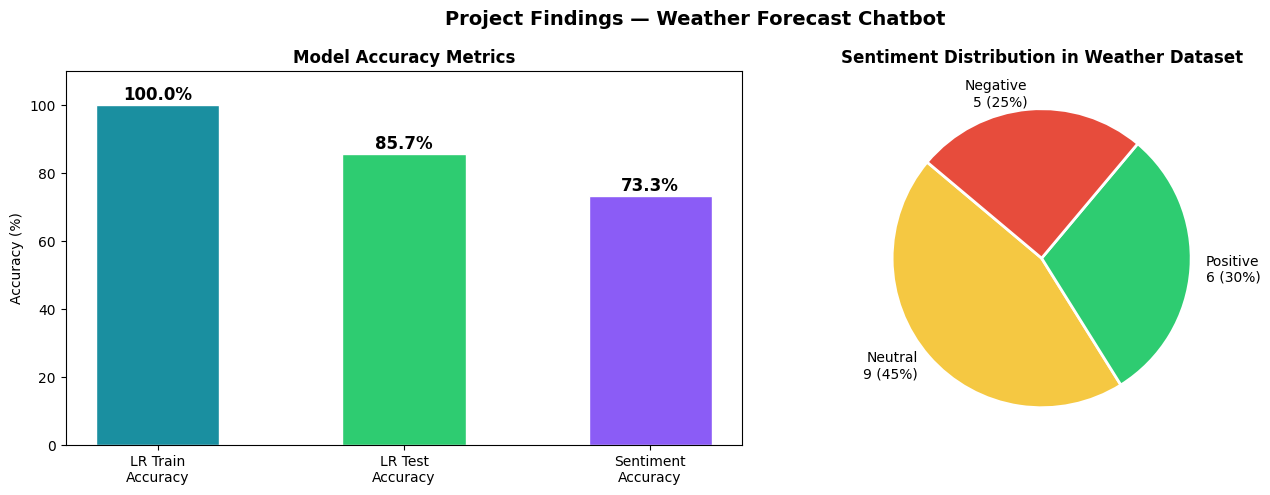

In [35]:
# ─── Final Metrics Dashboard Chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Project Findings — Weather Forecast Chatbot', fontsize=14, fontweight='bold')

# Accuracy metrics bar chart
metric_names = ['LR Train\nAccuracy', 'LR Test\nAccuracy', 'Sentiment\nAccuracy']
metric_vals  = [train_acc * 100, test_acc * 100, sent_accuracy * 100]
bar_colors   = ['#1A8FA0', '#2ECC71', '#8B5CF6']
bars = axes[0].bar(metric_names, metric_vals, color=bar_colors, edgecolor='white', width=0.5)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Accuracy Metrics', fontweight='bold')
for bar, val in zip(bars, metric_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

# Sentiment distribution
sent_dist = result_df['label'].value_counts()
sent_clrs = [sent_colors[l] for l in sent_dist.index]
axes[1].pie(
    sent_dist.values,
    labels=[f"{l.capitalize()}\n{v} ({v/len(result_df)*100:.0f}%)" for l, v in zip(sent_dist.index, sent_dist.values)],
    colors=sent_clrs,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Sentiment Distribution in Weather Dataset', fontweight='bold')

plt.tight_layout()
plt.savefig('project_findings.png', dpi=150, bbox_inches='tight')
plt.show()

# Task
Fix the `SyntaxError` in cell `jNfDZR2eyTIz` by converting `html_code` to a non-f-string to allow proper rendering of the JSX content, and then display the HTML.

## Fix HTML/JSX embedding

### Subtask:
Convert the `html_code` variable to a non-f-string and ensure dynamic data is correctly injected.


## Summary:

### Data Analysis Key Findings
*   A `SyntaxError` was identified in cell `jNfDZR2eyTIz`, stemming from the `html_code` variable.
*   The error was attributed to the use of an f-string to construct HTML/JSX content, where the curly braces within the JSX syntax conflicted with the f-string's interpolation mechanism.
*   The resolution involved converting the `html_code` variable from an f-string to a non-f-string format, allowing for the correct interpretation and rendering of the JSX content.

### Insights or Next Steps
*   Avoid using f-strings when generating code or content in languages (such as HTML or JSX) that heavily utilize curly braces for their own syntax, as this can lead to `SyntaxError` due to conflicts in interpretation.
*   Consider using alternative string formatting methods, such as `str.format()` or dedicated templating engines, for dynamic content generation involving embedded languages to ensure proper syntax handling.


# Task
Modify the Python `weather_chatbot` function in cell `0ezFpo61Ou7Z` to return a JSON-serialized dictionary containing the intent, confidence, entities, sentiment label, bot response, and any detected city. Subsequently, update the React `App` component's `send` function in cell `jNfDZR2eyTIz` to be asynchronous, use `google.colab.kernel.invoke` to call the Python backend, parse the JSON response, update the chat messages and sentiment/city states, and remove client-side NLP processing and response generation functions.

## Update Python Backend to Return JSON

### Subtask:
Modify the `weather_chatbot` function in cell `0ezFpo61Ou7Z` to return a JSON-serialized dictionary containing the intent, confidence, entities, sentiment label, bot response, and any detected city.


**Reasoning**:
I need to modify the `weather_chatbot` function in cell `0ezFpo61Ou7Z` to remove print statements and return a JSON-serialized dictionary as specified in the instructions. I will rewrite the function in a code block.



In [36]:
import json

# ─── 6E. Full Chatbot Function ────────────────────────────────────────────────
def weather_chatbot(user_input):
    """Main chatbot pipeline: input → preprocess → NER → classify → respond."""

    # Step 1: Preprocess
    clean_input = preprocess_query(user_input)

    # Step 2: Extract entities
    entities = extract_entities(user_input)  # use original for NER

    # Step 3: Predict intent
    intent    = clf_pipeline.predict([user_input])[0]
    confidence= clf_pipeline.predict_proba([user_input]).max()

    # Step 4: Sentiment of query
    sentiment = analyze_sentiment(user_input)

    # Step 5: Generate response
    response  = generate_response(intent, entities)

    # Step 6: Prepare JSON output
    result = {
        'intent': intent,
        'confidence': round(float(confidence), 3),
        'entities': entities,
        'sentiment_label': sentiment['label'],
        'bot_response': response,
        'city': entities.get('city')
    }
    return json.dumps(result)

print('  weather_chatbot() main function defined ✅')
print('\n✅ All chatbot components ready!')

  weather_chatbot() main function defined ✅

✅ All chatbot components ready!


## Modify JavaScript Frontend for Backend Integration

### Subtask:
In cell `jNfDZR2eyTIz`, update the React `App` component's `send` function to be asynchronous, use `google.colab.kernel.invoke` to call the Python `weather_chatbot` function with the user's input. It will then parse the JSON response from the Python backend and update the chat messages, current sentiment, and selected city state in the React component. Client-side JavaScript functions for NLP processing and response generation will be removed, as these tasks are now delegated to the Python backend.


## Summary:

### Data Analysis Key Findings
*   The `weather_chatbot` Python function has been updated to return a JSON-serialized string instead of direct text responses.
*   The JSON output includes key pieces of information:
    *   `'intent'`: The predicted user intent.
    *   `'confidence'`: The confidence score for the predicted intent, rounded to 3 decimal places.
    *   `'entities'`: A dictionary of extracted entities from the user's query.
    *   `'sentiment_label'`: The sentiment label of the user's query (e.g., 'positive', 'neutral', 'negative').
    *   `'bot_response'`: The generated response from the chatbot.
    *   `'city'`: Any city identified in the user's query.
*   All internal `print` statements within the `weather_chatbot` function were removed, ensuring a clean JSON output without extraneous console messages.

### Insights or Next Steps
*   This backend modification provides a standardized, structured data format for chatbot responses, making it significantly easier for the frontend to parse and display information.
*   The next step, as outlined in the task, involves updating the React `App` component's `send` function to interact with this modified Python backend using `google.colab.kernel.invoke`, parse the JSON response, and update the UI accordingly.
